In [ ]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_excel("/content/Online Retail.xlsx")

# quick check
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df.drop_duplicates()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.sort_values('InvoiceDate')
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']
df = df[df['UnitPrice'] > 0]
customer_monetary = df.groupby('CustomerID')['TotalSpend'].sum()
customer_monetary = customer_monetary.clip(lower=0)
customer_monetary.sort_values().head()

,TotalSpend
CustomerID,
12346,0.0
18274,0.0
16138,0.0
18268,0.0
13829,0.0


In [ ]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=30)

In [ ]:
df_past = df[df['InvoiceDate'] <= cutoff_date]
df_future = df[df['InvoiceDate'] > cutoff_date]

In [ ]:
future_spend = df_future.groupby('CustomerID')['TotalSpend'].sum()
future_spend = future_spend.clip(lower=0)
future_spend = future_spend.rename('FutureSpend30d')

In [ ]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalSpend': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['Monetary'] = rfm['Monetary'].clip(lower=0)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,2,0.00
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [ ]:
avg_order_value = df.groupby('CustomerID')['TotalSpend'].mean()
avg_order_value.name = "AvgOrderValue"
unique_products = df.groupby('CustomerID')['StockCode'].nunique()
unique_products.name = "UniqueProducts"
total_quantity = df.groupby('CustomerID')['Quantity'].sum()
total_quantity.name = "TotalQuantity"
avg_quantity = df.groupby('CustomerID')['Quantity'].mean()
avg_quantity.name = "AvgQuantity"
customer_lifetime = df.groupby('CustomerID')['InvoiceDate'].agg(['min','max'])

customer_lifetime['CustomerLifetime'] = (
    customer_lifetime['max'] - customer_lifetime['min']
).dt.days
orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

purchase_frequency = orders / (customer_lifetime['CustomerLifetime'] / 30)
purchase_frequency.name = "PurchaseFrequency"
extra_features = pd.concat([
    avg_order_value,
    unique_products,
    total_quantity,
    avg_quantity,
    purchase_frequency
], axis=1)

rfm = rfm.merge(extra_features, on='CustomerID', how='left')

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalQuantity,AvgQuantity,PurchaseFrequency
CustomerID,,,,,,,,
12346,325,2,0.00,0.000000,1,0,0.000000,inf
12347,1,7,4310.00,23.681319,103,2458,13.505495,0.575342
12348,74,4,1797.24,57.975484,22,2341,75.516129,0.425532
12349,18,1,1757.55,24.076027,73,631,8.643836,inf
12350,309,1,334.40,19.670588,17,197,11.588235,inf


In [ ]:
rfm = rfm.fillna(0)

In [ ]:
rfm = rfm.merge(future_spend, on='CustomerID', how='left')
rfm['FutureSpend30d'] = rfm['FutureSpend30d'].fillna(0)

In [ ]:
import numpy as np

rfm.replace([np.inf, -np.inf], 0, inplace=True)

In [ ]:
X = rfm.drop(columns=['FutureSpend30d'])
y = rfm['FutureSpend30d']

In [ ]:
X = X.drop(columns=['CustomerID'], errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42)
}

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])

results_df = results_df.sort_values(by="RMSE")

print(results_df)

               Model         MSE        RMSE        R2
0  Linear Regression  233.005669  813.415389  0.662117
1   Ridge Regression  233.005567  813.415389  0.662118
2   Lasso Regression  233.005383  813.415389  0.662118
3      Decision Tree  222.710743  813.415389 -1.820116
4      Random Forest  127.505781  813.415389  0.530009
5  Gradient Boosting  186.015506  813.415389 -0.878508
6        Extra Trees  154.772716  813.415389 -0.001338


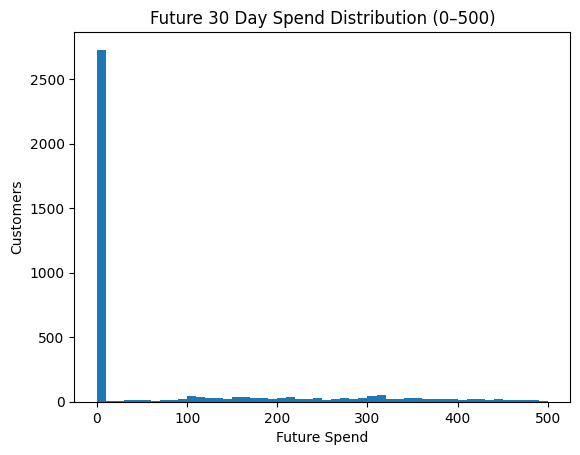

In [ ]:
import matplotlib.pyplot as plt
plt.hist(rfm['FutureSpend30d'], bins=50, range=(0, 500))

plt.title("Future 30 Day Spend Distribution (0–500)")
plt.xlabel("Future Spend")
plt.ylabel("Customers")

plt.show()

In [ ]:
import pickle

# Save trained model
with open('/content/my_data.pkl', 'wb') as f:
    pickle.dump(rfm, f)


print("Model saved successfully!")

Model saved successfully!
